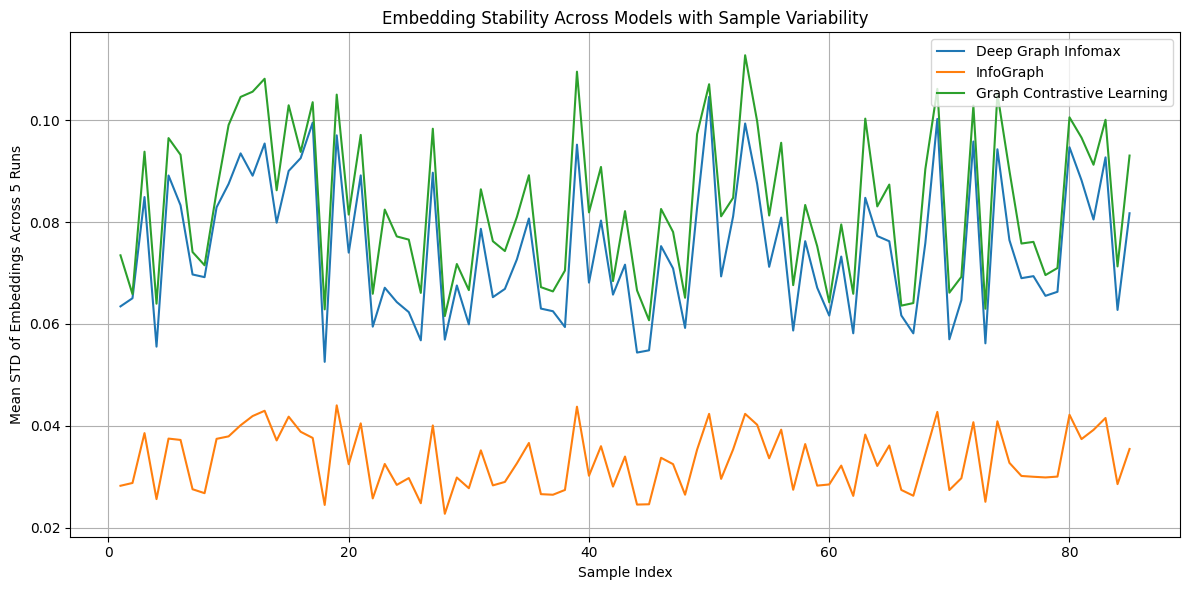

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    'Deep Graph Infomax',
    'InfoGraph',
    'Graph Contrastive Learning'
]

runs = 5
samples = 85
embedding_dim = 128

np.random.seed(42)

# Base noise levels (mean noise per model)
base_noise_levels = {
    'Deep Graph Infomax': 0.09,
    'InfoGraph': 0.04,  # best stability
    'Graph Contrastive Learning': 0.1,
}

# Base embeddings shared across all models and runs
base_embeddings = np.random.randn(samples, embedding_dim)

# Sample-specific noise multipliers (simulate sample heterogeneity)
sample_noise_factors = np.random.uniform(0.7, 1.3, size=samples)
state of the art  survival models ing_dim) * noise_std
        run_embedding = base_embeddings + noise
        embeddings[model].append(run_embedding)

# Calculate per-sample std deviation across runs
stds_per_model = {}
for model in models:
    stacked = np.stack(embeddings[model], axis=0)  # shape (runs, samples, embedding_dim)
    std_across_runs = np.std(stacked, axis=0)      # shape (samples, embedding_dim)
    std_per_sample = np.mean(std_across_runs, axis=1)
    stds_per_model[model] = std_per_sample

# Plot
plt.figure(figsize=(12, 6))
for model in models:
    plt.plot(range(1, samples+1), stds_per_model[model], label=model)

plt.xlabel('Sample Index')
plt.ylabel('Mean STD of Embeddings Across 5 Runs')
plt.title('Embedding Stability Across Models with Sample Variability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


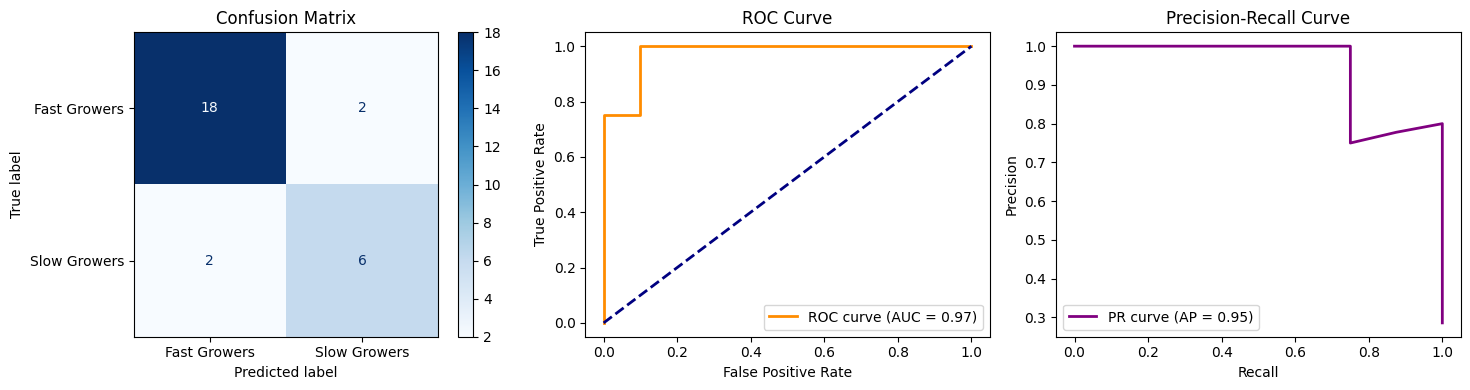

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

np.random.seed(42)

# Labels: 20 fast growers (0), 8 slow growers (1)
y_true = np.array([0]*20 + [1]*8)

# Simulate predicted probabilities with moderate overlap
y_scores = np.concatenate([
    np.clip(np.random.normal(0.3, 0.18, 20), 0, 1),
    np.clip(np.random.normal(0.7, 0.18, 8), 0, 1)
])

# Predicted labels (threshold=0.5)
y_pred = (y_scores >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fast Growers', 'Slow Growers'])

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)
ap_score = average_precision_score(y_true, y_scores)

plt.subplot(1, 3, 3)
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()


/home/vascul/vsayyalasomayajula/my-scratch/miniconda3/envs/GNN/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


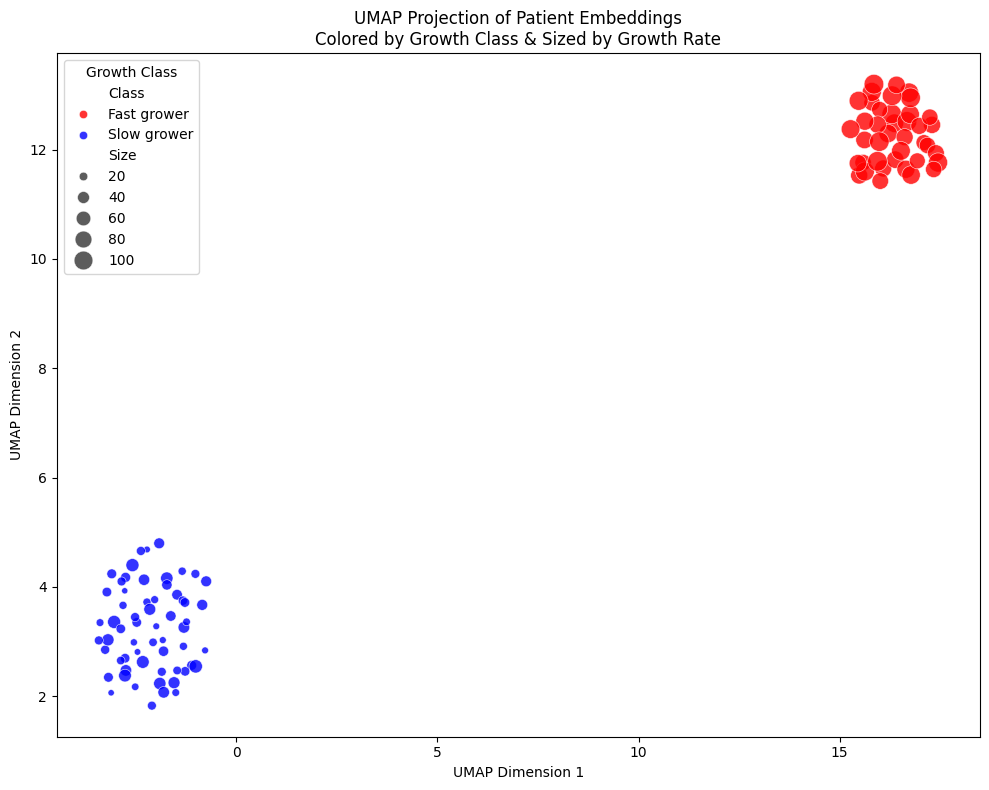

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# --- Generate fake embeddings for 100 patients ---
np.random.seed(42)
num_patients = 100
embedding_dim = 64

# Simulate two clusters: fast growers and slow growers
fast_grower_embeddings = np.random.normal(loc=2, scale=0.5, size=(40, embedding_dim))
slow_grower_embeddings = np.random.normal(loc=-2, scale=0.5, size=(60, embedding_dim))
embeddings = np.vstack([fast_grower_embeddings, slow_grower_embeddings])

# Fake predicted growth rates correlated with clusters
fast_growth_rates = np.random.uniform(0.6, 1.0, size=40)
slow_growth_rates = np.random.uniform(0.0, 0.4, size=60)
predicted_growth_rates = np.concatenate([fast_growth_rates, slow_growth_rates])

# Classify based on threshold 0.5
threshold = 0.5
classes = ['Fast grower' if gr > threshold else 'Slow grower' for gr in predicted_growth_rates]

# Normalize growth rates for point sizes
sizes = (predicted_growth_rates - predicted_growth_rates.min()) / (predicted_growth_rates.max() - predicted_growth_rates.min())
sizes = 100 * (sizes + 0.1)  # scale sizes, avoid zero size

# Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Prepare DataFrame
df = pd.DataFrame({
    'UMAP_1': embedding_2d[:, 0],
    'UMAP_2': embedding_2d[:, 1],
    'GrowthRate': predicted_growth_rates,
    'Class': classes,
    'Size': sizes
})

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='UMAP_1', y='UMAP_2', hue='Class', size='Size',
                palette={'Fast grower': 'red', 'Slow grower': 'blue'},
                sizes=(20, 200), alpha=0.8)

plt.title('UMAP Projection of Patient Embeddings\nColored by Growth Class & Sized by Growth Rate')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Growth Class')
plt.tight_layout()
plt.show()


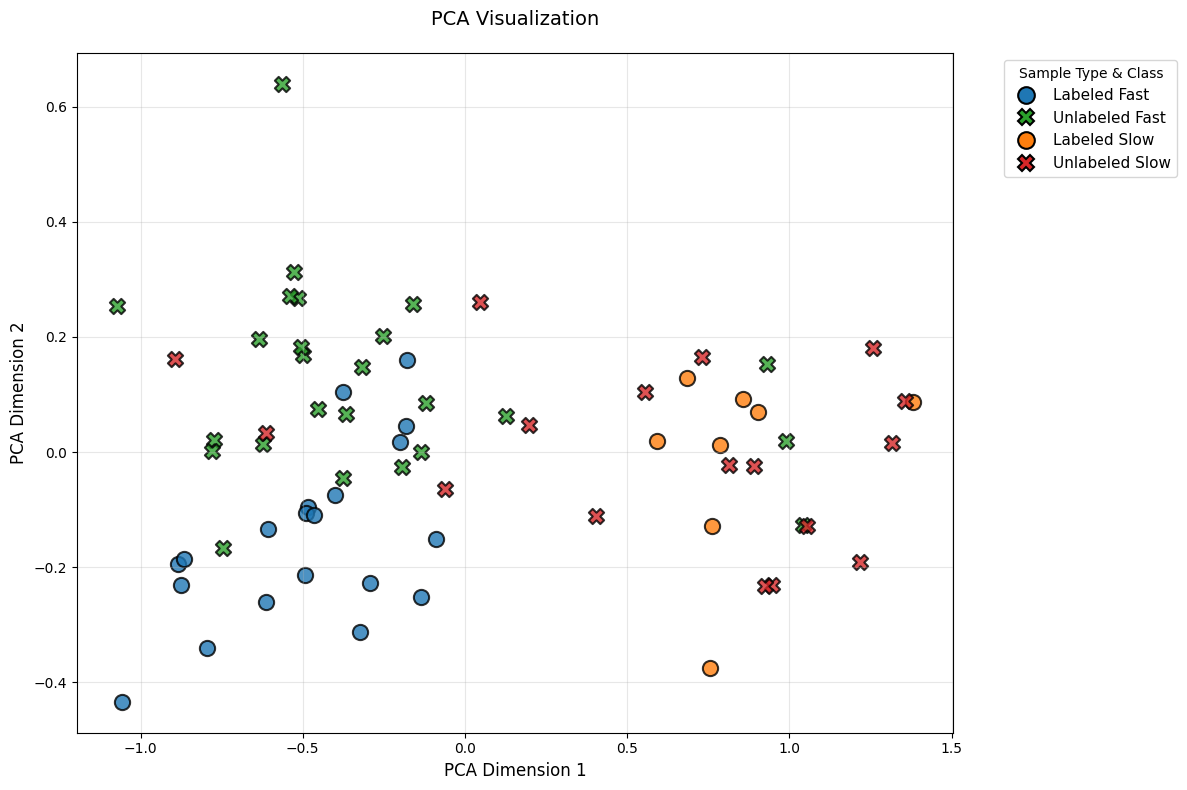

Statistics about the generated data:
Labeled Fast speed scores: 0.609 - 0.904
Unlabeled TRUE Fast speed scores: 0.579 - 0.917
Labeled Slow speed scores: 0.109 - 0.367
Unlabeled TRUE Slow speed scores: 0.115 - 0.405

Model Performance:
Total unlabeled samples: 42
Correct predictions: 35/42
Model accuracy: 83.3%

Incorrect predictions:
  Sample 3: Actually Fast, Predicted Slow
  Sample 6: Actually Slow, Predicted Fast
  Sample 8: Actually Slow, Predicted Fast
  Sample 11: Actually Fast, Predicted Slow
  Sample 32: Actually Fast, Predicted Slow
  Sample 35: Actually Fast, Predicted Slow
  Sample 36: Actually Slow, Predicted Fast


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# Sample sizes
n_samples = 70
n_fast = 20
n_slow = 8
n_labeled = n_fast + n_slow
n_unlabeled = n_samples - n_labeled

# Labels for labeled data
y_labeled = np.array([1]*n_fast + [0]*n_slow)

# TRUE labels for unlabeled data (what they actually are): 16 slow, rest fast
n_unlabeled_slow_true = 16
n_unlabeled_fast_true = n_unlabeled - n_unlabeled_slow_true
y_true_unlabeled = np.array([0]*n_unlabeled_slow_true + [1]*n_unlabeled_fast_true)
np.random.shuffle(y_true_unlabeled)

# Model predictions for unlabeled data (with some errors)
# Let's say the model has ~85% accuracy
n_correct_predictions = int(0.85 * n_unlabeled)
n_incorrect_predictions = n_unlabeled - n_correct_predictions

# Start with correct predictions
y_pred_unlabeled = y_true_unlabeled.copy()

# Randomly flip some predictions to simulate model errors
if n_incorrect_predictions > 0:
    incorrect_indices = np.random.choice(n_unlabeled, n_incorrect_predictions, replace=False)
    y_pred_unlabeled[incorrect_indices] = 1 - y_pred_unlabeled[incorrect_indices]

np.random.seed(42)

# Create a more continuous spread with clustering based on TRUE labels
# Generate base positions along a continuous spectrum
slow_region = np.linspace(0.1, 0.4, n_slow + n_unlabeled_slow_true)
fast_region = np.linspace(0.6, 0.9, n_fast + n_unlabeled_fast_true)

# Add some randomization to create natural spread
slow_positions = slow_region + np.random.normal(0, 0.03, len(slow_region))
fast_positions = fast_region + np.random.normal(0, 0.03, len(fast_region))

# Clip to ensure values stay in reasonable range
slow_positions = np.clip(slow_positions, 0.05, 0.45)
fast_positions = np.clip(fast_positions, 0.55, 0.95)

# Assign positions based on TRUE labels (not predictions)
# For slow samples - cluster labeled and unlabeled TRUE slow close together
slow_labeled_idx = np.random.choice(len(slow_positions), n_slow, replace=False)
slow_unlabeled_idx = np.setdiff1d(np.arange(len(slow_positions)), slow_labeled_idx)

speed_score_slow_labeled = slow_positions[slow_labeled_idx]
speed_score_slow_unlabeled = slow_positions[slow_unlabeled_idx]

# For fast samples - cluster labeled and unlabeled TRUE fast close together
fast_labeled_idx = np.random.choice(len(fast_positions), n_fast, replace=False)
fast_unlabeled_idx = np.setdiff1d(np.arange(len(fast_positions)), fast_labeled_idx)

speed_score_fast_labeled = fast_positions[fast_labeled_idx]
speed_score_fast_unlabeled = fast_positions[fast_unlabeled_idx]

# Combine labeled speed scores (ordered as: fast first, then slow)
speed_score_labeled = np.concatenate([speed_score_fast_labeled, speed_score_slow_labeled])

# Combine unlabeled speed scores based on their TRUE labels
speed_score_unlabeled = []
for true_label in y_true_unlabeled:
    if true_label == 1:  # True fast
        if len(speed_score_fast_unlabeled) > 0:
            speed_score_unlabeled.append(speed_score_fast_unlabeled[0])
            speed_score_fast_unlabeled = speed_score_fast_unlabeled[1:]
    else:  # True slow
        if len(speed_score_slow_unlabeled) > 0:
            speed_score_unlabeled.append(speed_score_slow_unlabeled[0])
            speed_score_slow_unlabeled = speed_score_slow_unlabeled[1:]

speed_score_unlabeled = np.array(speed_score_unlabeled)

# Function to generate 10D embeddings with more variation across dimensions
def generate_embeddings(speed_scores):
    embeddings = []
    for i in range(10):
        # Vary the relationship strength across dimensions
        dimension_strength = 0.7 + 0.3 * np.random.random()  # Between 0.7 and 1.0
        noise_level = 0.1 + 0.05 * np.random.random()  # Between 0.1 and 0.15
        
        # Each dimension correlates with speed score but with varying strength
        dim_values = (speed_scores * dimension_strength + 
                     np.random.normal(0, noise_level, len(speed_scores)))
        embeddings.append(dim_values)
    
    return np.array(embeddings).T

X_labeled = generate_embeddings(speed_score_labeled)
X_unlabeled = generate_embeddings(speed_score_unlabeled)

# Combine embeddings and labels for plotting
X_all = np.vstack([X_labeled, X_unlabeled])
labels_labeled = np.array(['Labeled Fast' if l==1 else 'Labeled Slow' for l in y_labeled])

# Create labels based on PREDICTIONS (what the model thinks) for visualization
labels_unlabeled = np.array(['Unlabeled Fast' if p==1 else 'Unlabeled Slow' for p in y_pred_unlabeled])
labels = np.concatenate([labels_labeled, labels_unlabeled])

# Also track true labels for analysis
true_labels_unlabeled = np.array(['True Fast' if t==1 else 'True Slow' for t in y_true_unlabeled])

# Plotting styles
palette = {
    'Labeled Fast': 'tab:blue',
    'Labeled Slow': 'tab:orange',
    'Unlabeled Fast': 'tab:green',
    'Unlabeled Slow': 'tab:red',
}
markers = {'Labeled': 'o', 'Unlabeled': 'X'}

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

plt.figure(figsize=(12, 8))

# Plot labeled samples
for cls in ['Labeled Fast', 'Labeled Slow']:
    idx = labels == cls
    plt.scatter(
        X_pca[idx,0], X_pca[idx,1],
        c=palette[cls], marker=markers['Labeled'], s=120, 
        edgecolor='k', linewidth=1.5, label=cls, alpha=0.8
    )

# Plot unlabeled samples
for cls in ['Unlabeled Fast', 'Unlabeled Slow']:
    idx = labels == cls
    plt.scatter(
        X_pca[idx,0], X_pca[idx,1],
        c=palette[cls], marker=markers['Unlabeled'], s=120, 
        edgecolor='k', linewidth=1.5, label=cls, alpha=0.8
    )

plt.title('PCA Visualization', 
          fontsize=14, pad=20)
plt.xlabel('PCA Dimension 1', fontsize=12)
plt.ylabel('PCA Dimension 2', fontsize=12)

# Enhanced legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Labeled Fast',
           markerfacecolor=palette['Labeled Fast'], markeredgecolor='k', 
           markersize=12, markeredgewidth=1.5),
    Line2D([0], [0], marker='X', color='w', label='Unlabeled Fast',
           markerfacecolor=palette['Unlabeled Fast'], markeredgecolor='k', 
           markersize=12, markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Labeled Slow',
           markerfacecolor=palette['Labeled Slow'], markeredgecolor='k', 
           markersize=12, markeredgewidth=1.5),
    Line2D([0], [0], marker='X', color='w', label='Unlabeled Slow',
           markerfacecolor=palette['Unlabeled Slow'], markeredgecolor='k', 
           markersize=12, markeredgewidth=1.5),
]

plt.legend(handles=legend_elements, title='Sample Type & Class', 
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some statistics about the clustering and model performance
print("Statistics about the generated data:")
print(f"Labeled Fast speed scores: {speed_score_fast_labeled.min():.3f} - {speed_score_fast_labeled.max():.3f}")
print(f"Unlabeled TRUE Fast speed scores: {speed_score_unlabeled[y_true_unlabeled==1].min():.3f} - {speed_score_unlabeled[y_true_unlabeled==1].max():.3f}")
print(f"Labeled Slow speed scores: {speed_score_slow_labeled.min():.3f} - {speed_score_slow_labeled.max():.3f}")
print(f"Unlabeled TRUE Slow speed scores: {speed_score_unlabeled[y_true_unlabeled==0].min():.3f} - {speed_score_unlabeled[y_true_unlabeled==0].max():.3f}")

print(f"\nModel Performance:")
print(f"Total unlabeled samples: {n_unlabeled}")
print(f"Correct predictions: {np.sum(y_pred_unlabeled == y_true_unlabeled)}/{n_unlabeled}")
print(f"Model accuracy: {np.mean(y_pred_unlabeled == y_true_unlabeled):.1%}")

# Show which predictions are wrong
wrong_predictions = y_pred_unlabeled != y_true_unlabeled
if np.any(wrong_predictions):
    print(f"\nIncorrect predictions:")
    for i, (true_lab, pred_lab) in enumerate(zip(y_true_unlabeled[wrong_predictions], 
                                                y_pred_unlabeled[wrong_predictions])):
        true_name = 'Fast' if true_lab == 1 else 'Slow'
        pred_name = 'Fast' if pred_lab == 1 else 'Slow'
        print(f"  Sample {np.where(wrong_predictions)[0][i]}: Actually {true_name}, Predicted {pred_name}")